In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pd.read_csv('Algerian_forest_fires_dataset.csv')

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [4]:
df=pd.read_csv('Algerian_forest_fires_dataset.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [6]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


## converting the dataset into two regions 
### bejia as region 0
### sidi abel as region 1
adding a new column as region


In [7]:
df.loc[:123,'Region']=0
df.loc[123:,'Region']=1

In [8]:
df[['Region']]=df[['Region']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       247 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.1+ KB


In [9]:
df=df.dropna().reset_index(drop=True)

In [10]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [11]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [12]:
# remove the 122nd row
df=df.drop(122).reset_index(drop=True)

In [13]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [14]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [15]:
## fixing spaces in column names
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [17]:
## changing into required datatype
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']]=df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [23]:
## changing the other datatype as float
objects=[features for features in df.columns if df[features].dtype=='O']
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [28]:
for i in objects:
    if i!='Classes':
        df[i]=df[i].astype(float)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [34]:
df.to_csv('Algerian_forest_fire_cleaned_dataset.csv',index=False)

## Exploratory Data Analysis

In [42]:
df_copy=df.drop(['day','month','year'],axis=1)
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,not fire,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,not fire,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,fire,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,not fire,1
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,not fire,1
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,not fire,1


In [43]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [44]:
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)


In [45]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

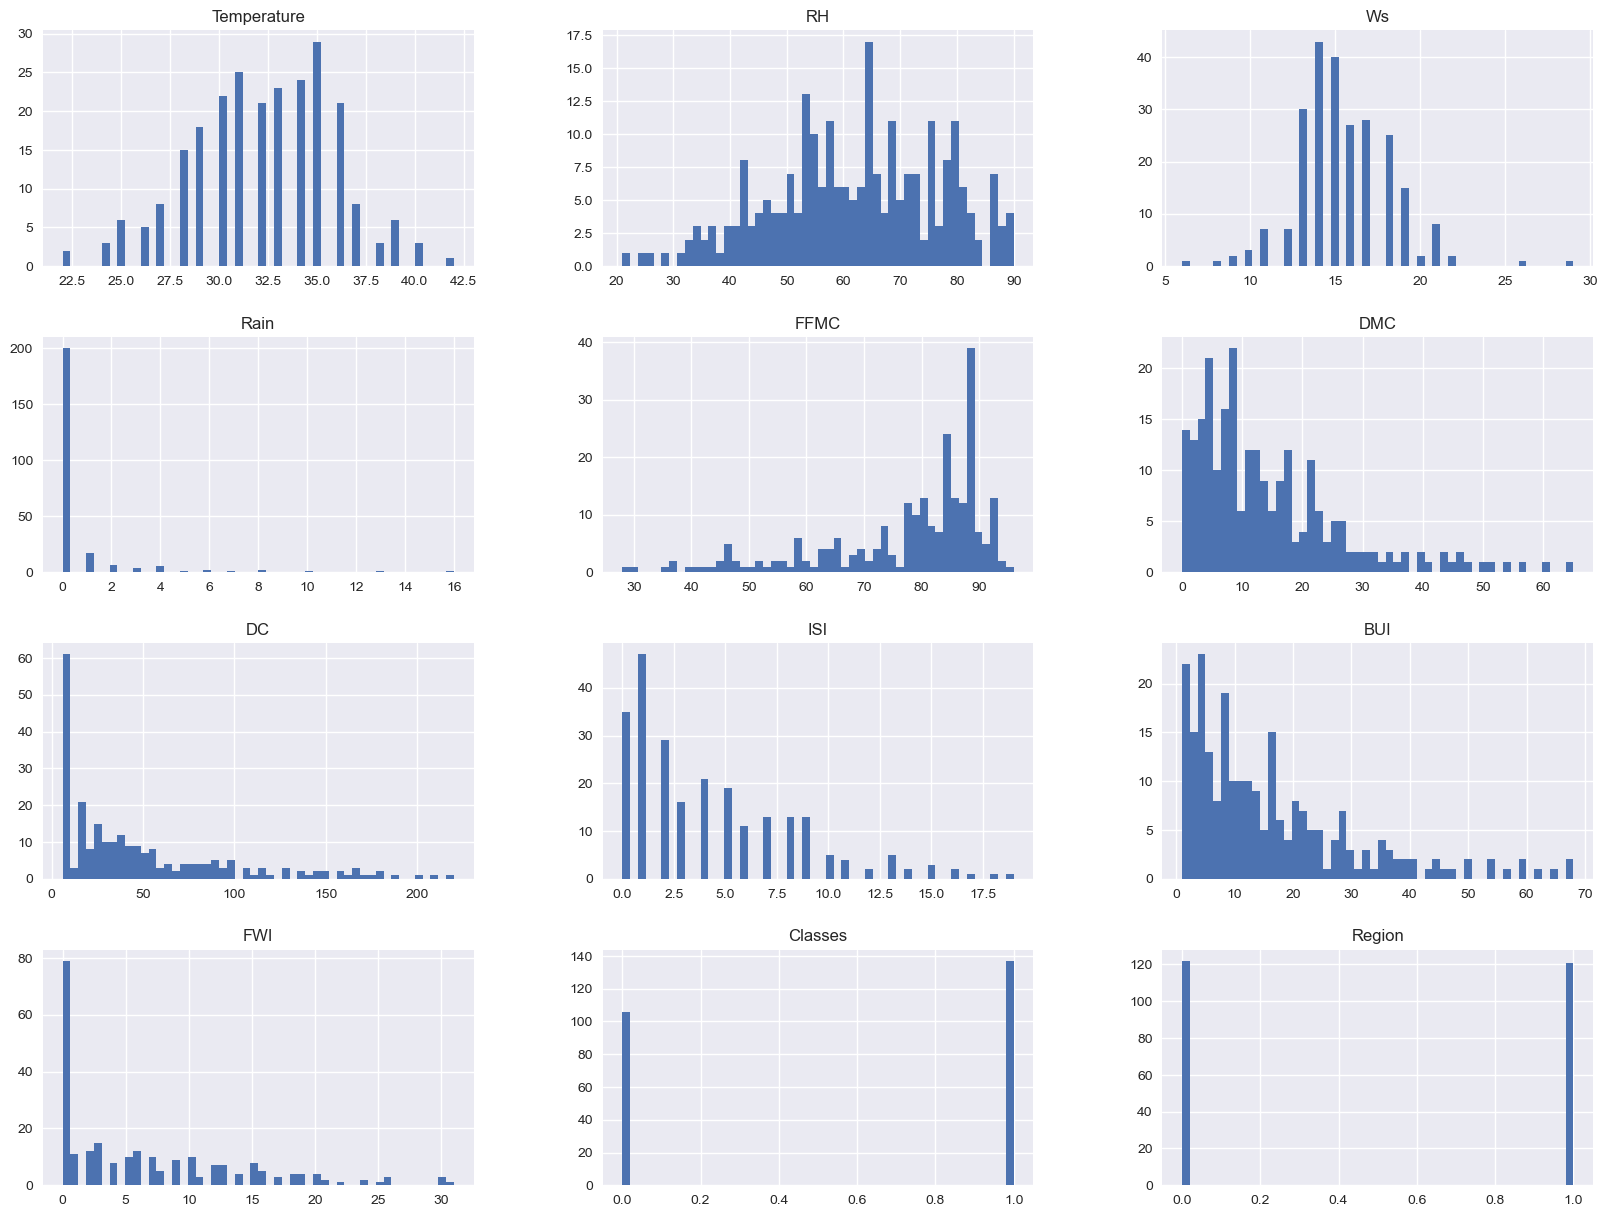

In [ ]:
## plotting density plot for all features

plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show

In [55]:
percentage=df_copy['Classes'].value_counts(normalize=True)*100
percentage

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

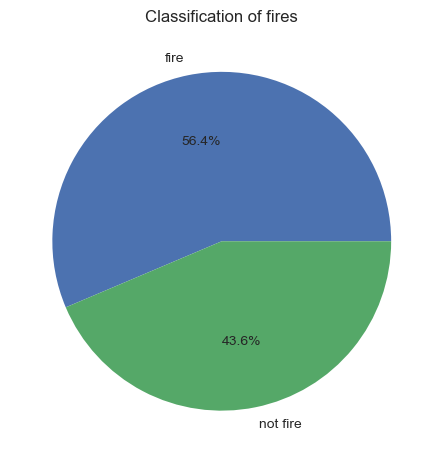

In [58]:
## plotting pie chart

label=['fire','not fire']
plt.pie(percentage,labels=label,autopct='%1.1f%%')
plt.title('Classification of fires')
plt.show()


In [60]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.322351,0.677443,0.485904,0.376003,0.601893,0.457610,0.561140,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.212946,-0.644674,-0.409140,-0.226695,-0.685212,-0.350936,-0.573959,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.170238,-0.166354,0.000571,0.078934,0.005143,0.031714,0.037493,-0.069964,-0.181160
Rain,-0.322351,0.212946,0.170238,1.000000,-0.496339,-0.253027,-0.268250,-0.294768,-0.265361,-0.270804,-0.326876,-0.033145
FFMC,0.677443,-0.644674,-0.166354,-0.496339,1.000000,0.604157,0.507689,0.729235,0.592232,0.679905,0.768896,0.222804
DMC,0.485904,-0.409140,0.000571,-0.253027,0.604157,1.000000,0.875447,0.680604,0.981594,0.875854,0.584676,0.191430
DC,0.376003,-0.226695,0.078934,-0.268250,0.507689,0.875447,1.000000,0.502481,0.941716,0.738373,0.510853,-0.078271
ISI,0.601893,-0.685212,0.005143,-0.294768,0.729235,0.680604,0.502481,1.000000,0.640407,0.918229,0.728555,0.269143
BUI,0.457610,-0.350936,0.031714,-0.265361,0.592232,0.981594,0.941716,0.640407,1.000000,0.856439,0.588203,0.089234
FWI,0.561140,-0.573959,0.037493,-0.270804,0.679905,0.875854,0.738373,0.918229,0.856439,1.000000,0.716741,0.197529


<Axes: >

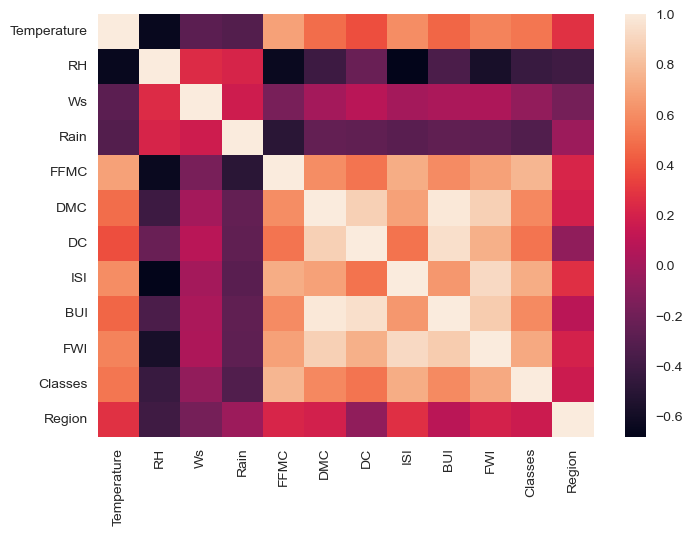

In [62]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

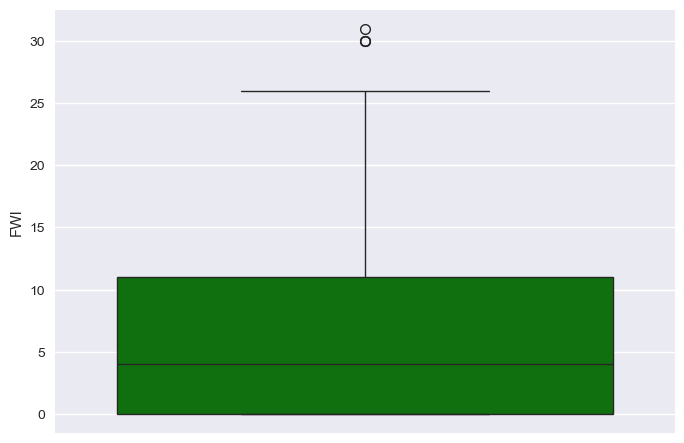

In [67]:
sns.boxplot(df_copy['FWI'],color='green')

In [68]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

In [69]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

Text(0.5, 1.0, 'fires in bejia region')

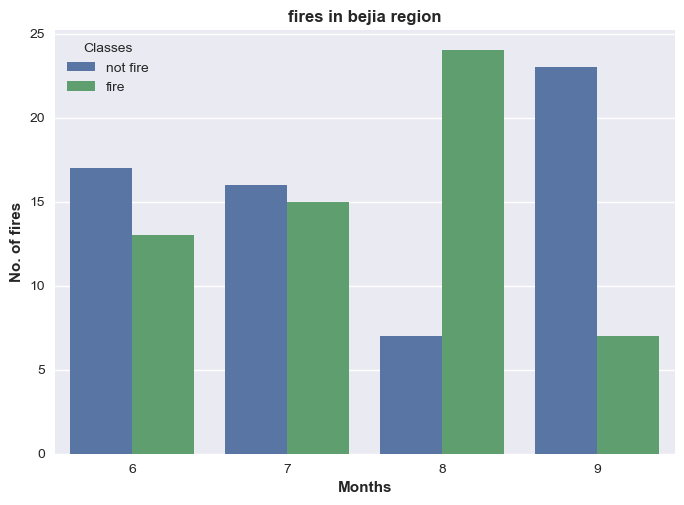

In [75]:
dftemp=df.loc[df['Region']==0]
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.xlabel("Months",weight='bold')
plt.ylabel("No. of fires",weight='bold')
plt.title("fires in bejia region",weight='bold')

Text(0.5, 1.0, 'fires in sidi-bel region')

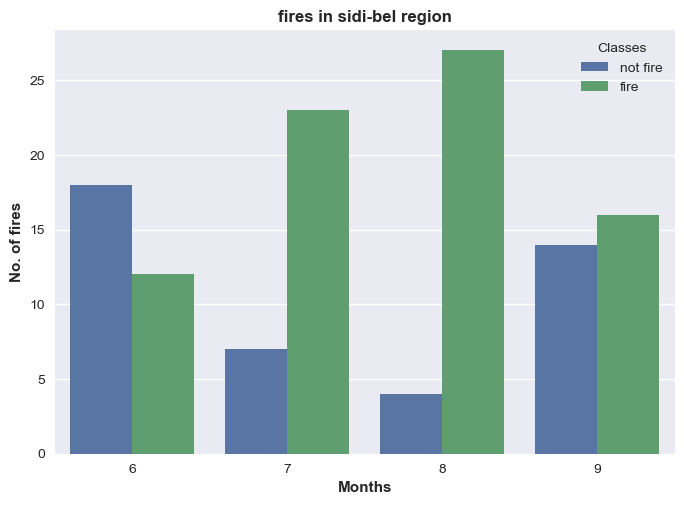

In [76]:
dftemp1=df.loc[df['Region']==1]
sns.countplot(x='month',hue='Classes',data=dftemp1)
plt.xlabel("Months",weight='bold')
plt.ylabel("No. of fires",weight='bold')
plt.title("fires in sidi-bel region",weight='bold')